[INFO] Initializing grid size: 120x120 | Time steps: 500


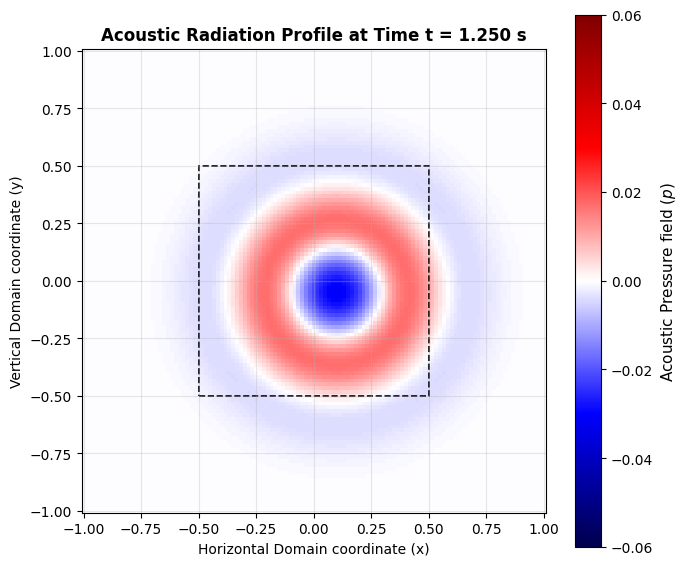

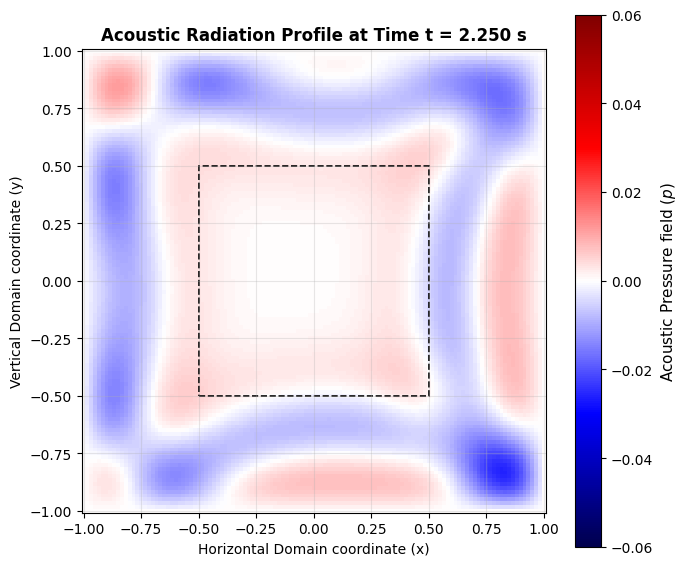

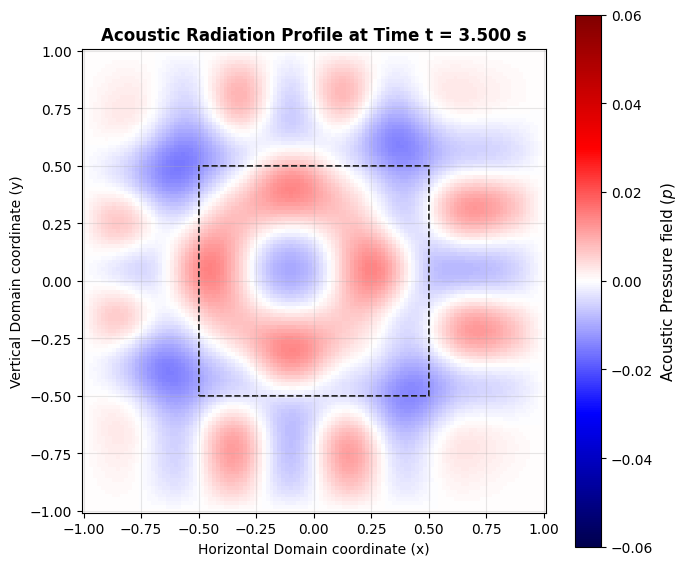

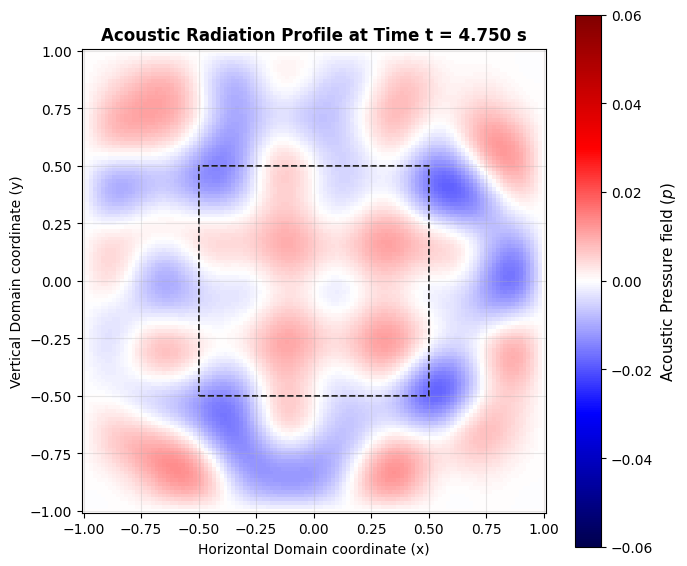

[SUCCESS] Wave simulation execution loop finished successfully.


In [3]:
import matplotlib.pyplot as plt
import numpy as np


class WaveSimulation2D:

    def __init__(self, L=1.0, N=100, nu=0.6, T=5.0):
        # Grid and physical parameters
        self.L = L
        self.N = N
        self.nu = nu
        self.T = T

        # Grid step derivations
        self.h = 2.0 * self.L / self.N
        self.dt = self.nu * self.h
        self.Nt = int(self.T / self.dt)

        # Spatial coordinate array allocations
        self.x = np.linspace(-self.L, self.L, self.N + 1)
        self.y = np.linspace(-self.L, self.L, self.N + 1)
        self.X, self.Y = np.meshgrid(self.x, self.y, indexing="ij")

        # Source signature metrics (Ricker Wavelet parameters)
        self.xs, self.ys = 0.1, -0.05
        self.sigma = 0.08
        self.f0 = 1.5
        self.t0 = 1.0

        # Precompute static spatial distribution profile g(x)
        self.g = np.exp(
            -((self.X - self.xs) ** 2 + (self.Y - self.ys) ** 2)
            / self.sigma**2
        )

        # Staggered field state allocations
        self.p = np.zeros((self.N + 1, self.N + 1))  # Node centered
        self.vx = np.zeros((self.N, self.N + 1))  # x-staggered half-nodes
        self.vy = np.zeros((self.N + 1, self.N))  # y-staggered half-nodes

    def ricker_time_signal(self, t):
        """Computes the instantaneous temporal signature of the Ricker wavelet."""
        if t < 0.0:
            return 0.0
        theta = np.pi * self.f0 * (t - self.t0)
        return (1.0 - 2.0 * theta**2) * np.exp(-(theta**2))

    def run_simulation(self):
        """Runs the time-stepping execution loops via fully vectorized operations."""
        print(
            f"[INFO] Initializing grid size: {self.N}x{self.N} | Time steps: {self.Nt}"
        )

        # Define visualization checkpoints to display wave structures
        plot_steps = [
            int(self.Nt * 0.25),
            int(self.Nt * 0.45),
            int(self.Nt * 0.70),
            int(self.Nt * 0.95),
        ]

        for n in range(self.Nt):
            t_n = n * self.dt
            t_half = (n + 0.5) * self.dt

            # --- Step 1: Update vx field (centered at t = n + 1/2) ---
            self.vx[:, :] -= self.nu * (self.p[1:, :] - self.p[:-1, :])

            # --- Step 2: Update vy field (centered at t = n + 1/2) ---
            self.vy[:, :] -= self.nu * (self.p[:, 1:] - self.p[:, :-1])

            # --- Step 3: Compute spatial divergence parts ---
            div_vx = self.vx[1:, 1:-1] - self.vx[:-1, 1:-1]
            div_vy = self.vy[1:-1, 1:] - self.vy[1:-1, :-1]

            # --- Step 4: Advance pressure field to t = n + 1 ---
            source = (
                self.dt * self.g[1:-1, 1:-1] * self.ricker_time_signal(t_half)
            )
            self.p[1:-1, 1:-1] -= self.nu * (div_vx + div_vy) - source

            # --- Step 5: Enforce homogeneous Dirichlet condition p = 0 on \Sigma ---
            self.p[0, :] = 0.0
            self.p[-1, :] = 0.0
            self.p[:, 0] = 0.0
            self.p[:, -1] = 0.0

            # --- Diagnostics Visualization ---
            if n in plot_steps:
                self.plot_snapshot(t_n)

        print("[SUCCESS] Wave simulation execution loop finished successfully.")

    def plot_snapshot(self, t_current):
        """Generates publication-quality figures tracking structural evolution."""
        fig, ax = plt.subplots(figsize=(7, 6), dpi=100)

        # Create clear colored map distribution layout
        cmap_limit = 0.06
        mesh = ax.pcolormesh(
            self.X,
            self.Y,
            self.p,
            cmap="seismic",
            vmin=-cmap_limit,
            vmax=cmap_limit,
            shading="auto",
        )

        # Include structural reference boundaries (Gamma and Sigma markers)
        ax.add_patch(
            plt.Rectangle(
                (-0.5, -0.5),
                1.0,
                1.0,
                fill=False,
                edgecolor="black",
                linestyle="--",
                linewidth=1.2,
                label=r"$\Gamma$",
            )
        )

        cbar = fig.colorbar(mesh, ax=ax)
        cbar.set_label(r"Acoustic Pressure field ($p$)", fontsize=11)

        ax.set_title(
            f"Acoustic Radiation Profile at Time t = {t_current:.3f} s",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("Horizontal Domain coordinate (x)", fontsize=10)
        ax.set_ylabel("Vertical Domain coordinate (y)", fontsize=10)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()  # Forces Colab to render the inline plot graph immediate at step n


# =====================================================================
#  MANDATORY EXECUTION CODE BLOCK FOR GOOGLE COLAB RUNTIME
# =====================================================================
# 1. Instantiate the simulation object instance
simulator = WaveSimulation2D(L=1.0, N=120, nu=0.6, T=5.0)

# 2. Invoke the driver loop method to process calculations and draw maps
simulator.run_simulation()